# Example: Developing a YAML Config for a Standard Plot
This notebook demonstrates how to create a new standard plot with a `.yaml` config file.  When placed in a proper directory, the config file can be plotted by name using the method `AnalyzeTimeSeries.plot_time_series_multipanel()` and will be included in the "plot all" method `AnalyzeTimeSeries.plot_all_quicklook()`.

In [1]:
from modules.quicklook.src.analyze_time_series import AnalyzeTimeSeries
from datetime import datetime
%matplotlib inline

Load the database by creating an AnalyzeTimeSeries object.
(You can also use `db_path = 'kpf_ts.db'` to use a SQLite version of the TSDB.)

In [2]:
myTS = AnalyzeTimeSeries(backend='psql')

INFO: Starting AnalyzeTimeSeries
INFO: Starting KPF_TSDB
INFO: Jupyter Notebook environment detected.
INFO: Base data directory: /data/L0
INFO: Backend: psql
INFO: Table prefix: tsdb_
INFO: PSQL server: 127.0.0.1
INFO: PSQL username: timeseriesdba
INFO: PSQL user role: admin
INFO: Metadata table exists.
INFO: Metadata table read.
INFO: Data tables exist.


To build a new `.yaml` config file, it's helpful to start with an example (see below).  Copy an example file to a subdirectory of `KPF-Pipeline/static/tsdb_plot_configs/` and start modifying.  (Note that the subdirectory that it is copied to must have an `__init.py__` file in it for `AnalyzeTimeSeries` to pick it up automatically.)

Next, see what the config file produces.  For example, the file `KPF-Pipeline/static/tsdb_plot_configs/autocal-etalon_snr.yaml` makes the plot below.

INFO: Plotting from config: /code/KPF-Pipeline/static/tsdb_plot_configs/Cal/autocal-etalon_snr.yaml


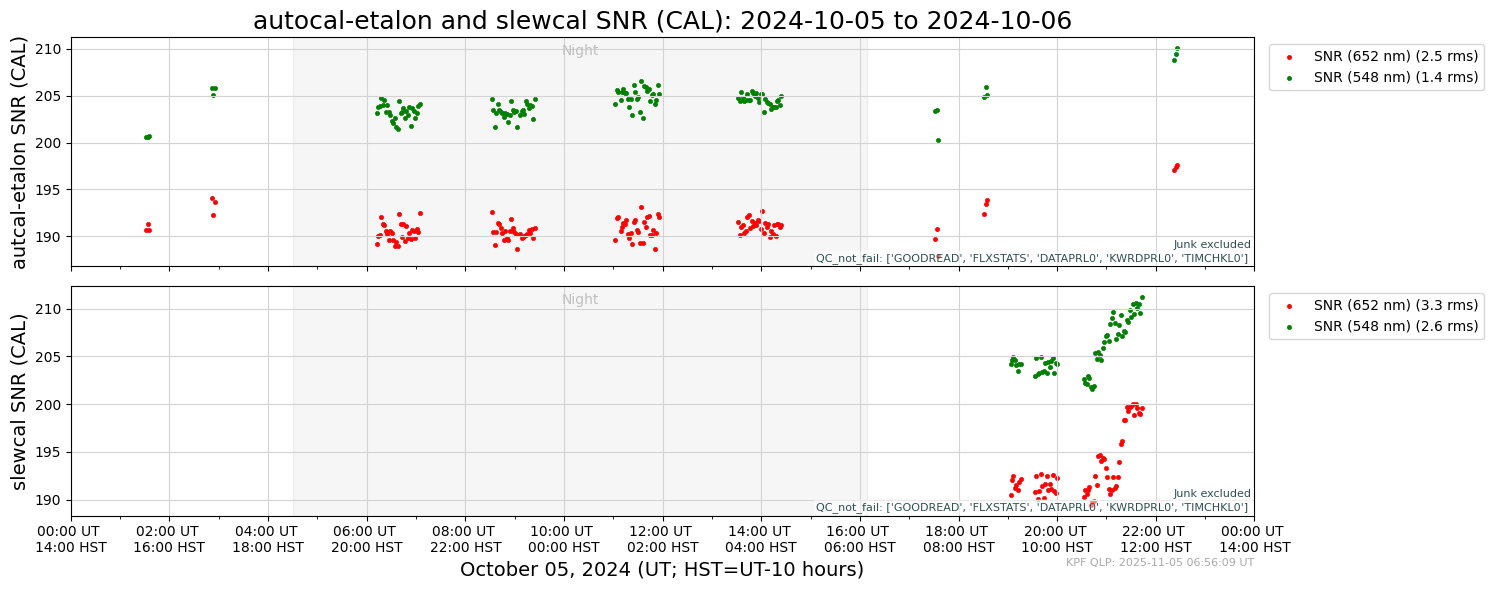

In [3]:
start_date = datetime(2024, 10,  5)
end_date   = datetime(2024, 10,  6)
myTS.plot_time_series_multipanel('autocal-etalon_snr', start_date=start_date, end_date=end_date, show_plot=True, clean=True)

The `.yaml` file that produced that output is shown below.  Note that there are two panels specified.  In the first panel, the TSDB columns `SNRCL548` and `SNRCL652` are plotted vs. time.  Other parameters of the panels are set in the `panelvars` including the plot type (`scatter`) and plotting attributes (label, plot point characteristics).  The section `paneldict` has a set of keyword/value pairs that specify the shared vertical axis label, criteria for including data in the panel (not marked 'Junk' and not failing a set of QC tests indicated by their keywords), and the set of `OBJECT` names for data to be included in the plots (`only_object`).

In [4]:
!cat /code/KPF-Pipeline/static/tsdb_plot_configs/Cal/autocal-etalon_snr.yaml

description: autocal-etalon and slewcal SNR
plot_type: time_series_multipanel
panel_arr:
  - panelvars:
      - col: SNRCL548
        plot_type: scatter
        plot_attr:
          label: SNR (548 nm)
          marker: .
          linewidth: 0.5
          color: green
      - col: SNRCL652
        plot_type: scatter
        plot_attr:
          label: SNR (652 nm)
          marker: .
          linewidth: 0.5
          color: red
    paneldict:
      ylabel: "autcal-etalon SNR (CAL)"
      not_junk: true
      qc_not_fail: 'GOODREAD, FLXSTATS, DATAPRL0, KWRDPRL0, TIMCHKL0'
      not_junk: true
      legend_frac_size: 0.20
      only_object: 
        - autocal-etalon-all-night
        - autocal-etalon-all-eve
        - autocal-etalon-all-morn
  - panelvars:
      - col: SNRCL548
        plot_type: scatter
        plot_attr:
          label: SNR (548 nm)
          marker: .
          linewidth: 0.5
          color: green
      - col: SNRCL652
        plot_type: scatter
        plot_attr:

The full set of parameters that can be included in the `.yaml` files is listed in the docstring below.

In [5]:
help(myTS.plot_time_series_multipanel)

Help on method plot_time_series_multipanel in module modules.quicklook.src.analyze_time_series:

plot_time_series_multipanel(plotdict, start_date=None, end_date=None, hatch_service_missions=True, clean=False, fig_path=None, show_plot=False, log_savefig_timing=False) method of modules.quicklook.src.analyze_time_series.AnalyzeTimeSeries instance
    Generate a multi-panel time series plot from a KPF TSDB. Each subplot is configured
    via a dict (or YAML file path), enabling control over filters, transforms, and style.
    
    Parameters
    ----------
    plotdict : str or dict
        Path to a named YAML config or a dict with key 'panel_arr' (list of panel dicts).
    start_date, end_date : datetime, optional
        Query window (UT). Defaults if None: start=2020-01-01, end=2040-01-01. The code
        may tighten to the data’s min/max timestamps.
    hatch_service_missions : bool, default=True
        Overlay hatched spans from self.get_service_mission_df() (UT_start_date, UT_end_